# Part 3: ML-Based Forecasting — Lag Features + Gradient Boosting
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Modern Industry Default

Yesterday Sarah saw that classical methods (Naive, Seasonal Naive, ETS) struggle on the multi-seasonal holiday data. Each handles only one seasonality at a time.

Today she tries the modern industry default: **turn the time series into a TABULAR REGRESSION problem with LAG FEATURES, then use the same gradient boosting from L04.**

The trick: for each day, add columns for past values (`lag_1`, `lag_7`, `lag_365`). The model learns: "given yesterday's revenue, last week's same day, and last year's same day, predict today's." This naturally handles MULTIPLE seasonalities — just add more lag columns.

**By the end of this notebook you will be able to:**
- Build lag features from a time series
- Train a `HistGradientBoostingRegressor` on the resulting tabular dataset
- Forecast recursively (predict day t+1, plug into lag for day t+2, ...)
- Compare against the classical baselines from NB 03 — and likely beat them

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 4.5)

print("✅ Libraries loaded — HistGradientBoostingRegressor ready")

✅ Libraries loaded — HistGradientBoostingRegressor ready


## Step 1 — Setup + train/test split (same 90-day window as NB 03)

In [2]:
df = pd.read_csv("data/northstar_daily_revenue.csv", parse_dates=["date"])
df = df.set_index("date")
y = df["revenue_gbp"]

TEST_SIZE = 90
print(f"Series length: {len(y)} days")
print(f"Test size:     {TEST_SIZE} days (last 90 days)")

Series length: 731 days
Test size:     90 days (last 90 days)


## Step 2 — Build lag features

For the ML forecasting, we will use `HistGradientBoostingRegressor`, a high-performance gradient boosting model that builds decision trees sequentially to correct previous errors. By capturing complex non-linear interactions, it learns how lag and calendar features combine to drive demand spikes, without needing explicit decomposition or fixed seasonal assumptions.

To turn the time series into a supervised learning problem, we convert past values and calendar structure into predictive features for each day.

For each day t, add columns:
- `lag_1` — y[t-1] — yesterday (short-term momentum)
- `lag_7` — y[t-7] — same day last week (weekly cycle)
- `lag_30` — y[t-30] — roughly a month ago (no true monthly cycle — we keep it to *test* whether it helps; see Step 7)
- `lag_365` — y[t-365] — same day last year (captures annual seasonality)
- `dayofweek` — encoded day of week (catches weekend lift)
- `month` — encoded month (catches holiday season)
- `dayofyear` — day of year, 1–365/366 (a fine-grained position-in-year signal)
- `weekofyear` — ISO week number (another annual-position signal; see the fun fact below)

We deliberately choose lags that match *real recurring periods* (day, week, year) rather than evenly spaced intervals. `lag_30` is the exception — there's no genuine 30-day cycle in this data, so we include it as a worked example of how to check whether a candidate feature actually earns its place (Step 7).

The first 365 rows will have NaN for `lag_365` — we drop them before training.

In [3]:
def build_features(series):
    # Convert a time series into a tabular dataframe with lag features.
    feat = pd.DataFrame(index=series.index)
    feat["target"]    = series
    feat["lag_1"]     = series.shift(1)
    feat["lag_7"]     = series.shift(7)
    feat["lag_30"]    = series.shift(30)
    feat["lag_365"]   = series.shift(365)
    feat["dayofweek"] = series.index.dayofweek
    feat["month"]     = series.index.month
    feat["dayofyear"] = series.index.dayofyear
    feat["weekofyear"] = series.index.isocalendar().week.astype(int)
    return feat

features = build_features(y)
print("Feature columns:", list(features.columns))
print(f"Shape before dropna: {features.shape}")

# Drop rows with NaN (the first 365 days, because of lag_365)
features_clean = features.dropna()
print(f"Shape after dropna:  {features_clean.shape}")
print()
features_clean.head()

Feature columns: ['target', 'lag_1', 'lag_7', 'lag_30', 'lag_365', 'dayofweek', 'month', 'dayofyear', 'weekofyear']
Shape before dropna: (731, 9)
Shape after dropna:  (366, 9)



,target,lag_1,lag_7,lag_30,lag_365,dayofweek,month,dayofyear,weekofyear
date,,,,,,,,,
2024-12-31,10914.48,10156.17,11104.88,11535.59,9297.99,1,12,366,1
2025-01-01,9924.26,10914.48,11464.24,10321.83,8727.85,2,1,1,1
2025-01-02,9923.83,9924.26,9998.96,10805.03,9568.17,3,1,2,1
2025-01-03,10919.50,9923.83,10776.79,11225.24,9687.98,4,1,3,1
2025-01-04,12242.70,10919.50,12090.55,11019.96,8920.65,5,1,4,1


> ### 🎲 Fun fact — why `2024-12-31` shows `weekofyear = 1`
>
> Look at the table above: **2024-12-31** has `weekofyear = 1`, not `52` or `53`. That's not a bug — it's the **ISO 8601** week-numbering rule that `pandas` `.isocalendar()` follows.
>
> ISO weeks aren't just the calendar year chopped into 7-day blocks. The rule is:
> > **A week belongs to whichever year contains that week's Thursday** (equivalently: week 1 is the week holding the year's first Thursday).
>
> - 2024-12-31 is a **Tuesday**, in the week running **Mon 2024-12-30 → Sun 2025-01-05**.
> - That week's **Thursday is 2025-01-02**, which lives in 2025.
> - So the whole week — including Dec 30–31, 2024 — counts as **week 1 of ISO year 2025**.
>
> The reverse also happens: the first days of January can land in week 52/53 of the *previous* ISO year (e.g. Jan 1 on a Saturday).
>
> **Does it matter here?** Not for the model — `weekofyear` is just a consistent, repeatable integer feature, so gradient boosting uses it fine either way. It would only bite if you tried to join `weekofyear` back to a specific calendar year, where you'd also need `.isocalendar().year`. If you want a label that never jumps across year boundaries, `dayofyear` (1–365/366) is the cleaner choice — and it's already a feature above.


## Step 3 — Split into train / test on a DATE boundary

Same boundary as NB 03 — last 90 days as test. Use the date index, not row positions, so the split is clean.

In [4]:
# Split by date — use everything before the last 90 days for training
test_start = y.index[-TEST_SIZE]

train_set = features_clean.loc[features_clean.index < test_start]
test_set  = features_clean.loc[features_clean.index >= test_start]

print(f"Train: {len(train_set)} rows (after dropping first 365 days for lag_365)")
print(f"Test:  {len(test_set)} rows")

X_train = train_set.drop(columns=["target"])
y_train = train_set["target"]
X_test  = test_set.drop(columns=["target"])
y_test  = test_set["target"]

Train: 276 rows (after dropping first 365 days for lag_365)
Test:  90 rows


## Step 4 — Train HistGradientBoostingRegressor

Same algorithm family as L04 (HistGradientBoostingClassifier) — just the regression version. Hyperparameters: a smallish learning rate + 200 iterations + early stopping for safety.

In [5]:
# Gradient Boosting model for time-series forecasting using lag + calendar features
model = HistGradientBoostingRegressor(
    max_iter=200,              # number of boosting iterations (trees)
    learning_rate=0.05,        # lower = more stable, slower learning
    max_depth=6,               # limits tree complexity to reduce overfitting
    early_stopping=True,       # stops if validation score stops improving
    validation_fraction=0.15,  # hold-out split for early stopping
    n_iter_no_change=20,       # patience for early stopping
    random_state=42,           # reproducibility
)

# Fit model on engineered features (lags + calendar variables)
model.fit(X_train, y_train)

# One-step-ahead prediction:
# Uses known lag values (y[t-1], y[t-7], y[t-365]) + calendar features
y_pred_direct = pd.Series(model.predict(X_test), index=y_test.index)

# Evaluation metrics
mae  = mean_absolute_error(y_test, y_pred_direct)              # average absolute £ error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_direct))      # penalises large spikes more
mape = (np.abs(y_test - y_pred_direct) / y_test).mean() * 100  # percentage error

# Results
print(f"ML forecast (one-step-ahead, with known lag values):")
print(f"  MAE:  £{mae:,.0f}")
print(f"  RMSE: £{rmse:,.0f}")
print(f"  MAPE: {mape:.1f}%")

# Benchmark comparison against classical models (same test window)
print(f"\nFor comparison from NB 03 on the same 90-day test window:")
print(f"  Naive:          MAE £3,346  · MAPE 29.3%")
print(f"  Seasonal Naive: MAE £2,400  · MAPE 20.7%")
print(f"  ETS-weekly:     MAE £2,246  · MAPE 19.3%")

ML forecast (one-step-ahead, with known lag values):
  MAE:  £1,398
  RMSE: £1,668
  MAPE: 12.2%

For comparison from NB 03 on the same 90-day test window:
  Naive:          MAE £3,346  · MAPE 29.3%
  Seasonal Naive: MAE £2,400  · MAPE 20.7%
  ETS-weekly:     MAE £2,246  · MAPE 19.3%


### 💡 What you should notice — and a caveat

- **One-step-ahead** ML forecast is usually MUCH better than classical methods. That's because we're using THE ACTUAL `lag_1` (yesterday's known revenue) at each test day — which is "cheating" relative to a multi-step forecast.
- **For real deployment**, day t+90 doesn't know day t+89's actual revenue. We need RECURSIVE forecasting — see Step 5.

This is the most important distinction in time-series ML:
- **One-step-ahead** with known lags → optimistic; useful only when forecasting one step in the future
- **Recursive (rolling)** → realistic for multi-step forecasts; errors compound

## Step 5 — Recursive (rolling) forecast for the full 90-day horizon

To predict day t+1: use real lag values (last train day's revenue).
To predict day t+2: use the PREDICTED day t+1 as `lag_1`.
And so on. Errors compound but this mirrors real deployment.

We hold OUT the test set, then forecast 90 days one at a time, plugging each prediction into the next day's lag values.

In [6]:
def recursive_forecast(model, history_y: pd.Series, future_index: pd.DatetimeIndex):
    # Predict each future day one at a time, plugging predictions into the lag features for the next day.
    history = history_y.copy()
    predictions = []
    for date in future_index:
        # Build the feature row for THIS date using current history
        row = {
            "lag_1":   history.iloc[-1],
            "lag_7":   history.iloc[-7]   if len(history) >= 7   else history.iloc[-1],
            "lag_30":  history.iloc[-30]  if len(history) >= 30  else history.iloc[-1],
            "lag_365": history.loc[date - pd.Timedelta(days=365)]
                       if (date - pd.Timedelta(days=365)) in history.index
                       else history.iloc[-1],
            "dayofweek": date.dayofweek,
            "month":     date.month,
            "dayofyear": date.dayofyear,
            "weekofyear": date.isocalendar().week,
        }
        # Predict — keep only the columns this model was actually trained on,
        # so the same function works whether or not lag_30 is included.
        X_row = pd.DataFrame([row])
        if hasattr(model, "feature_names_in_"):
            X_row = X_row[list(model.feature_names_in_)]
        pred = model.predict(X_row)[0]
        predictions.append(pred)
        # Append prediction to history so it's available for future lags
        history.loc[date] = pred

    return pd.Series(predictions, index=future_index)


y_pred_recursive = recursive_forecast(
    model,
    history_y=y.loc[y.index < test_start],
    future_index=y_test.index,
)

mae_rec  = mean_absolute_error(y_test, y_pred_recursive)
rmse_rec = np.sqrt(mean_squared_error(y_test, y_pred_recursive))
mape_rec = (np.abs(y_test - y_pred_recursive) / y_test).mean() * 100

print(f"ML forecast (RECURSIVE — predictions plugged into lags):")
print(f"  MAE:  £{mae_rec:,.0f}")
print(f"  RMSE: £{rmse_rec:,.0f}")
print(f"  MAPE: {mape_rec:.1f}%")

ML forecast (RECURSIVE — predictions plugged into lags):
  MAE:  £2,438
  RMSE: £2,911
  MAPE: 21.0%


## Step 6 — Visualise the forecast vs actual

Notice that the recursive forecast drifts below the actual holiday run-up. Recursive forecasting tends to under-capture trend because forecast errors are fed back into future lag features, causing error accumulation and forecasts to gradually revert towards the model's average learned behaviour.

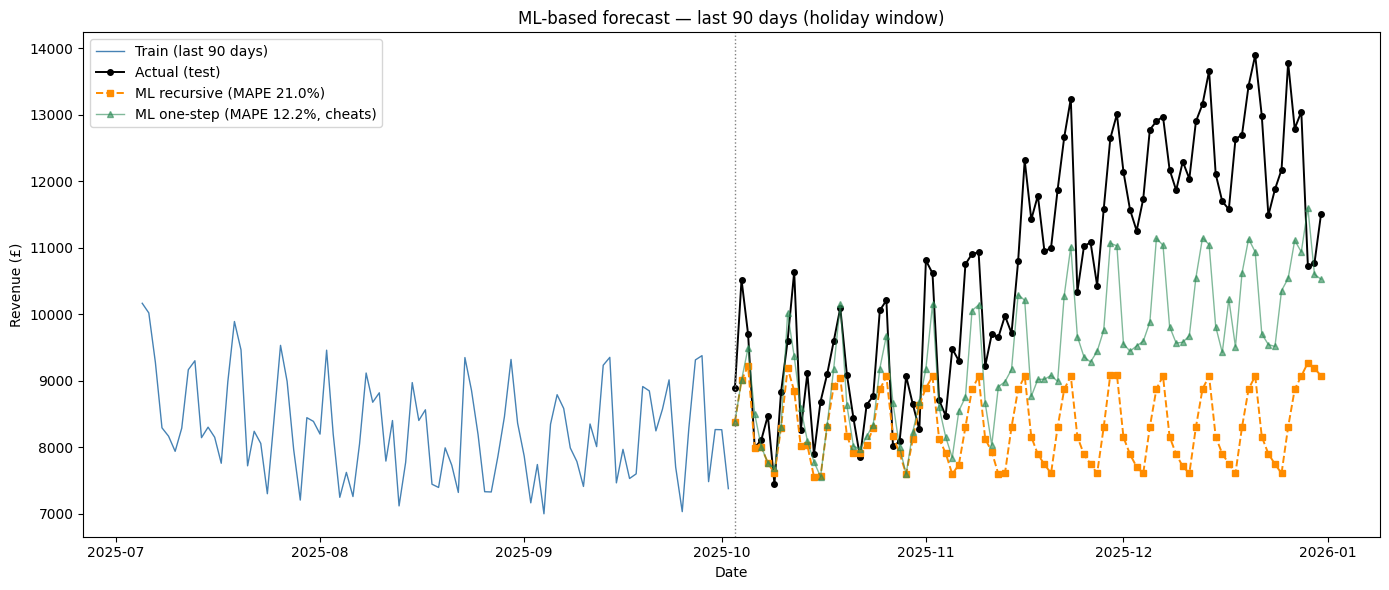

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Last 90 days of train for context
ax.plot(y.iloc[-(TEST_SIZE+90):-TEST_SIZE].index,
        y.iloc[-(TEST_SIZE+90):-TEST_SIZE].values,
        color="steelblue", linewidth=1.0, label="Train (last 90 days)")
ax.plot(y_test.index, y_test.values, "o-", color="black",
        markersize=4, linewidth=1.4, label="Actual (test)")
ax.plot(y_pred_recursive.index, y_pred_recursive.values, "s--", color="darkorange",
        markersize=4, linewidth=1.4, label=f"ML recursive (MAPE {mape_rec:.1f}%)")
ax.plot(y_pred_direct.index, y_pred_direct.values, "^-", color="seagreen",
        markersize=4, linewidth=1.0, alpha=0.6,
        label=f"ML one-step (MAPE {mape:.1f}%, cheats)")

ax.axvline(y_test.index[0], color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("ML-based forecast — last 90 days (holiday window)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 7 — Impact Analysis: Uncovering Drivers (lag_7) and Noise (lag_30)

Now that the model is trained, we want to identify which features are most important for its forecasts. Unlike standard Feature Importance, which measures how often a feature is used when building the trees, **Permutation Importance** measures how much forecasting performance worsens when a feature's values are randomly shuffled in the validation set.

For example, if the model uses `lag_7` (sales from 7 days ago), we randomly shuffle the `lag_7` values while keeping all other features unchanged. If the forecast error increases significantly, the model relies heavily on `lag_7`; if the error changes little, the feature contributes little useful information.

Although shuffling is used, this does not cause time-series leakage because the model has already been trained — we are simply testing the trained model, not learning from future data. Features causing the largest performance drop are the most important.

Permutation importance (higher = more critical to the forecast):
   feature  importance
     lag_7     241.424
 dayofweek     100.217
   lag_365      20.437
     lag_1       7.954
weekofyear       4.287
     month       0.000
 dayofyear       0.000
    lag_30     -16.452


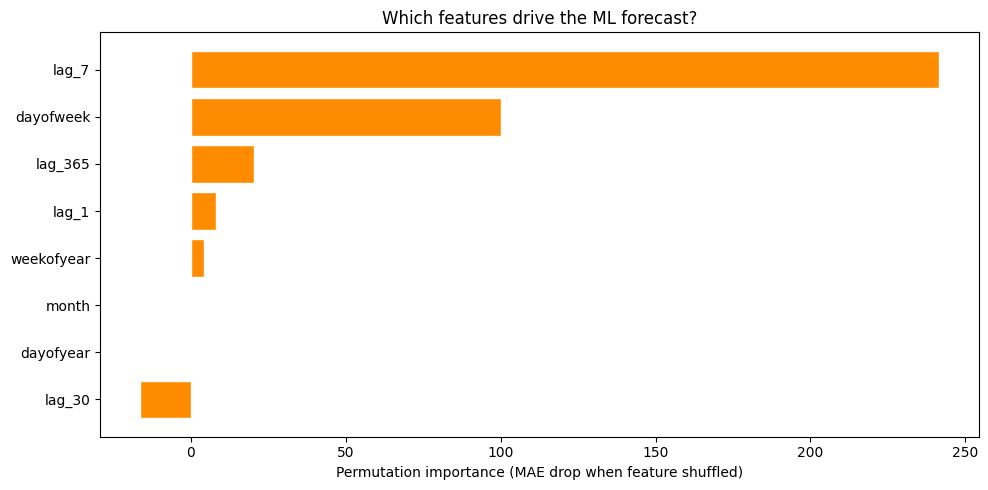

In [8]:
importances = model.feature_importances_ if hasattr(model, "feature_importances_") else None

# HistGradientBoostingRegressor doesn't expose feature_importances_ directly;
# use permutation importance instead
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error",
)

imp_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": result.importances_mean,
}).sort_values("importance", ascending=False)

print("Permutation importance (higher = more critical to the forecast):")
print(imp_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="darkorange", edgecolor="white")
ax.set_xlabel("Permutation importance (MAE drop when feature shuffled)")
ax.set_title("Which features drive the ML forecast?")
plt.tight_layout()
plt.show()

### 💡 What this tells us

Permutation importance measures how much forecast accuracy drops when a feature's signal is destroyed. The results reveal three key insights:

- **Weekly seasonality dominates.** `lag_7` (same day last week) is by far the most important feature, with `dayofweek` adding useful, non-redundant information about the weekend-versus-weekday pattern.
- **Annual seasonality matters more than short-term momentum.** `lag_365` ranks well above `lag_1`, showing that recurring yearly patterns and holiday effects are more valuable than yesterday's value for this dataset.
- **Some features add little value — or even noise.** `month` and `dayofyear` are effectively ignored, while `lag_30` has *negative* importance, meaning shuffling it actually improved performance. This suggests it may be adding noise.

> ⚠️ **Interpret this with care — it's a single run on one window.** These scores come from permuting features on *one* 90-day test window. Permutation importance is noisy: it depends on which window you score, the random shuffles, and `n_repeats`. Treat the ranking as a *hypothesis*, not a verdict — a feature flagged as "noise" here might matter on another window. The optional check below (Step 7b) shows the honest way to act on such a hint: actually drop the feature, re-train, and re-evaluate under the protocol you care about.

## 🟡 Step 7b (optional) — Test the hypothesis: does dropping `lag_30` actually help?

*Optional / self-study. Skipping this won't affect the rest of the notebook — we keep `lag_30` either way.*

Permutation importance flagged `lag_30` as possible noise (negative importance on the one-step test window). But that was a *single permutation score on one window* — suggestive, not decisive. The honest way to decide whether to remove a feature is to actually drop it, re-train, and re-evaluate under the SAME forecasting protocol we care about (one-step **and** recursive).

We retrain an identical model with `lag_30` removed and compare it head-to-head with the full model.

In [9]:
# Retrain an identical model WITHOUT lag_30 and compare to the full model.
X_train_no30 = X_train.drop(columns=["lag_30"])
X_test_no30  = X_test.drop(columns=["lag_30"])

model_no30 = HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.05, max_depth=6,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
    random_state=42,
)
model_no30.fit(X_train_no30, y_train)

# One-step-ahead (known lags)
pred_os_no30 = pd.Series(model_no30.predict(X_test_no30), index=y_test.index)
mae_os_no30  = mean_absolute_error(y_test, pred_os_no30)
mape_os_no30 = (np.abs(y_test - pred_os_no30) / y_test).mean() * 100

# Recursive (deployment-realistic) — recursive_forecast auto-selects this model's columns
pred_rec_no30 = recursive_forecast(model_no30, history_y=y.loc[y.index < test_start], future_index=y_test.index)
mae_rec_no30  = mean_absolute_error(y_test, pred_rec_no30)
mape_rec_no30 = (np.abs(y_test - pred_rec_no30) / y_test).mean() * 100

print("Effect of removing lag_30 (90-day holiday test window):")
print(f"{'':<22}{'WITH lag_30':>16}{'WITHOUT lag_30':>16}")
print(f"{'one-step MAE':<22}{f'£{mae:,.0f}':>16}{f'£{mae_os_no30:,.0f}':>16}")
print(f"{'one-step MAPE':<22}{f'{mape:.1f}%':>16}{f'{mape_os_no30:.1f}%':>16}")
print(f"{'recursive MAE':<22}{f'£{mae_rec:,.0f}':>16}{f'£{mae_rec_no30:,.0f}':>16}")
print(f"{'recursive MAPE':<22}{f'{mape_rec:.1f}%':>16}{f'{mape_rec_no30:.1f}%':>16}")
print()
print("→ Removing lag_30 does NOT improve the forecast — both one-step and recursive")
print("  errors are marginally WORSE without it. The negative permutation score came from")
print("  a single window and didn't generalise. Lesson: validate feature removal against your")
print("  real forecasting protocol before trusting it. We KEEP lag_30 for the rest of the notebook.")

Effect of removing lag_30 (90-day holiday test window):
                           WITH lag_30  WITHOUT lag_30
one-step MAE                    £1,398          £1,493
one-step MAPE                    12.2%           12.9%
recursive MAE                   £2,438          £2,450
recursive MAPE                   21.0%           21.1%

→ Removing lag_30 does NOT improve the forecast — both one-step and recursive
  errors are marginally WORSE without it. The negative permutation score came from
  a single window and didn't generalise. Lesson: validate feature removal against your
  real forecasting protocol before trusting it. We KEEP lag_30 for the rest of the notebook.


## Step 8 — Final comparison: ALL methods on the same test window

In [10]:
# Re-create classical forecasts on the same setup
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_train_full = y.iloc[:-TEST_SIZE]

# Naive
naive_pred = pd.Series([y_train_full.iloc[-1]] * TEST_SIZE, index=y_test.index)

# Seasonal Naive (lag-7) — tile the last 7 training days across the horizon (same as NB 03)
last_season = y_train_full.iloc[-7:].values
snaive_pred = pd.Series([last_season[i % 7] for i in range(TEST_SIZE)], index=y_test.index)

# ETS-weekly
ets_weekly = ExponentialSmoothing(y_train_full, trend="add", seasonal="add", seasonal_periods=7).fit()
ets_pred = pd.Series(ets_weekly.forecast(steps=TEST_SIZE).values, index=y_test.index)

def metrics(y_true, y_pred, name):
    return {
        "method":   name,
        "MAE":      mean_absolute_error(y_true, y_pred),
        "RMSE":     np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_pct": (np.abs(y_true - y_pred) / y_true).mean() * 100,
    }

comparison = pd.DataFrame([
    metrics(y_test, naive_pred,            "Naive"),
    metrics(y_test, snaive_pred,           "Seasonal Naive (lag-7)"),
    metrics(y_test, ets_pred,              "ETS-weekly"),
    metrics(y_test, y_pred_recursive,      "ML recursive"),
]).set_index("method")

print(comparison.round(2).to_string())
print()

winner = comparison["MAE"].idxmin()
print(f"WINNER on MAE: {winner}  (MAE = £{comparison.loc[winner, 'MAE']:,.0f})")

                            MAE     RMSE  MAPE_pct
method                                            
Naive                   3345.53  3758.12     29.33
Seasonal Naive (lag-7)  2400.13  2873.35     20.74
ETS-weekly              2246.25  2692.26     19.33
ML recursive            2438.39  2910.98     20.98

WINNER on MAE: ETS-weekly  (MAE = £2,246)


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### 💡 What you should see — and what's confusing

- **On THIS particular 90-day holiday window**, ML recursive lands around MAPE ~21% — roughly tied with Seasonal Naive, and a touch behind ETS-weekly (~19%). The window contains a holiday regime change AND requires 90 recursive steps that compound errors.
- The **ML one-step** result (MAPE ~12%) is what real deployment looks like when you can retrain daily — only the first step's error compounds, not 90 of them.
- **Don't read a single-window result as any method's "true" performance.** Step 9 (next) cross-validates the ML model *and* the classical baselines with `TimeSeriesSplit` over several rolling windows. ML's mean CV MAE (~£1,570) is far below the £2,438 it scored on this one slice — but, importantly, ETS cross-validates to ~£1,550 over the same folds, so once the comparison is fair the two are essentially tied.

**Sarah's Friday plan:** judge every model on cross-validated windows, not a single deployment-window snapshot — then pick based on the full picture (multi-step error, one-step error, and operational simplicity).

## Step 9 — Time-series cross-validation: ML vs the classical baselines

The comparison in Step 8 comes from a SINGLE test window. That's risky — a method can look good or bad purely because of which 90 days it happened to land on (here, a holiday run-up). To judge the methods fairly we evaluate them on several windows and average.

`TimeSeriesSplit` gives you multiple train/test splits where the test set is ALWAYS later than the train set. We use 3 splits, each with a 90-day test window (`lag_365` needs ~1 year of training data before each split, so we use fewer/larger folds rather than many tiny ones). This rolls forward through the data — like simulating real deployment 3 times. Unlike standard k-fold cross-validation, the data is never shuffled, and future observations are never allowed to appear in the training set.

**Crucially, we cross-validate the ML model AND the classical baselines (ETS-weekly, Seasonal Naive) on the *same* folds.** Comparing a cross-validated ML number against a single-window classical number would be unfair — the whole point is to put every method through the identical rolling-window test before drawing a conclusion.

First we visualise the split structure, then we **re-train and forecast each method on each fold** and average the MAE.

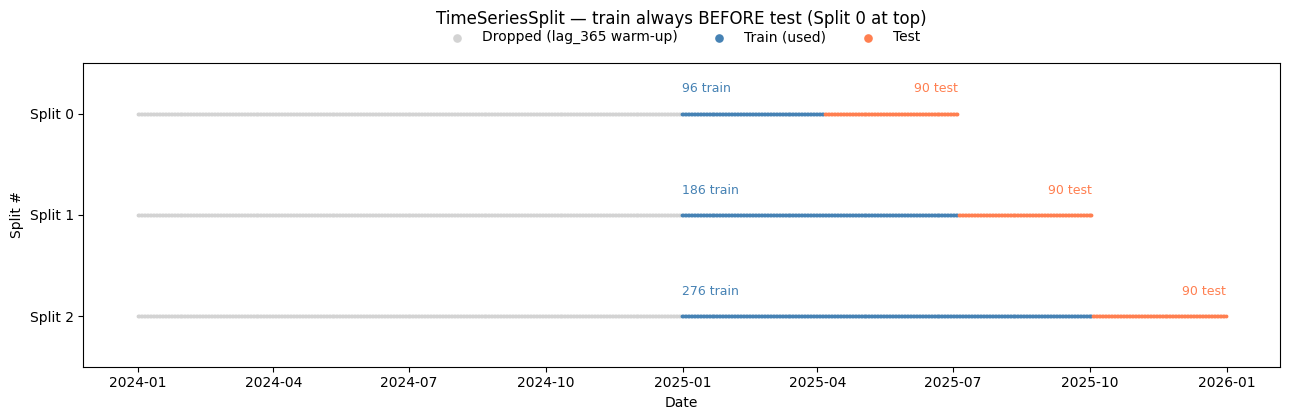

Each row is one split. Train (blue) is always to the LEFT of test (coral).
Grey = the first 365 days, dropped because lag_365 has no value yet.
Train counts shown (96 / 186 / 276) match the rows actually used in the CV cell below.


In [11]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 3
CV_TEST_SIZE = 90
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=CV_TEST_SIZE)

# lag_365 needs a full year of history, so the first 365 days can't be used for training.
# The chart reflects the ACTUAL usable training rows (what the CV cell below trains on),
# NOT the raw split indices — otherwise the labels wouldn't match the printed fold sizes.
warmup_end = y.index[365]

fig, ax = plt.subplots(figsize=(13, 4.3))

for split_idx, (train_idx, test_idx) in enumerate(tscv.split(y)):
    # Reverse the vertical order so split 0 sits at the TOP
    row = N_SPLITS - 1 - split_idx
    train_dates = y.index[train_idx]
    used   = train_dates[train_dates >= warmup_end]   # rows actually used to train (lag_365 available)
    warmup = train_dates[train_dates <  warmup_end]    # first 365 days, dropped

    ax.scatter(warmup, [row] * len(warmup), s=3, color="lightgray",
               label="Dropped (lag_365 warm-up)" if split_idx == 0 else None)
    ax.scatter(used, [row] * len(used), s=3, color="steelblue",
               label="Train (used)" if split_idx == 0 else None)
    ax.scatter(y.index[test_idx], [row] * len(test_idx), s=3, color="coral",
               label="Test" if split_idx == 0 else None)
    ax.text(used[0], row + 0.18, f"{len(used)} train",
            color="steelblue", fontsize=9, va="bottom")
    ax.text(y.index[test_idx[-1]], row + 0.18, f"{len(test_idx)} test",
            color="coral", fontsize=9, va="bottom", ha="right")

ax.set_xlabel("Date")
ax.set_ylabel("Split #")
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Split {N_SPLITS - 1 - r}" for r in range(N_SPLITS)])
ax.set_ylim(-0.5, N_SPLITS - 0.5)
ax.set_title("TimeSeriesSplit — train always BEFORE test (Split 0 at top)", pad=28)
# Legend above the plot so it never overlaps the split bars
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, markerscale=3, frameon=False)
plt.tight_layout()
plt.show()

print("Each row is one split. Train (blue) is always to the LEFT of test (coral).")
print("Grey = the first 365 days, dropped because lag_365 has no value yet.")
print("Train counts shown (96 / 186 / 276) match the rows actually used in the CV cell below.")

In [12]:
# Cross-validate EVERY method on the SAME folds: re-train + forecast on each fold, then average MAE.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

cv_maes        = []  # ML recursive
ets_cv_maes    = []  # ETS-weekly
snaive_cv_maes = []  # Seasonal Naive (lag-7)
fold_rows      = []  # for a tidy per-fold table

for split_idx, (train_idx, test_idx) in enumerate(tscv.split(y)):
    fold_test_index = y.index[test_idx]
    fold_test_start = fold_test_index[0]
    fold_true       = y.loc[fold_test_index]
    hist            = y.loc[y.index < fold_test_start]   # everything before this fold's test window

    # --- ML: features for THIS fold (rows strictly before the fold's test window) ---
    fold_features = build_features(y).dropna()
    fold_train = fold_features.loc[fold_features.index < fold_test_start]
    X_tr = fold_train.drop(columns=["target"])
    y_tr = fold_train["target"]

    fold_model = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=6,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        random_state=42,
    )
    fold_model.fit(X_tr, y_tr)
    fold_pred = recursive_forecast(fold_model, history_y=hist, future_index=fold_test_index)
    ml_mae = mean_absolute_error(fold_true, fold_pred)
    cv_maes.append(ml_mae)

    # --- Classical baselines on the SAME fold (train = everything before the fold test window) ---
    ets_fold = ExponentialSmoothing(hist, trend="add", seasonal="add", seasonal_periods=7).fit()
    ets_pred = pd.Series(ets_fold.forecast(steps=CV_TEST_SIZE).values, index=fold_test_index)
    ets_mae  = mean_absolute_error(fold_true, ets_pred)
    ets_cv_maes.append(ets_mae)

    last_season = hist.iloc[-7:].values
    sn_pred = pd.Series([last_season[i % 7] for i in range(CV_TEST_SIZE)], index=fold_test_index)
    sn_mae  = mean_absolute_error(fold_true, sn_pred)
    snaive_cv_maes.append(sn_mae)

    fold_rows.append({
        "Split":          split_idx,
        "Train rows":     len(X_tr),
        "Test window":    f"{fold_test_index[0].date()} → {fold_test_index[-1].date()}",
        "ML recursive":   ml_mae,
        "ETS-weekly":     ets_mae,
        "Seasonal Naive": sn_mae,
    })

# --- Per-fold MAE table (mirrors the tidy layout used in Step 8) ---
per_fold = pd.DataFrame(fold_rows).set_index("Split")
money_cols = ["ML recursive", "ETS-weekly", "Seasonal Naive"]
per_fold_display = per_fold.copy()
for c in money_cols:
    per_fold_display[c] = per_fold_display[c].map(lambda v: f"£{v:,.0f}")
print("Per-fold MAE (each method re-trained on that fold's training window):")
print(per_fold_display.to_string())
print()

# --- Summary table: cross-validated mean MAE vs the single Step-8 window, side by side ---
cv_mae_mean  = np.mean(cv_maes)
ets_mae_mean = np.mean(ets_cv_maes)
sn_mae_mean  = np.mean(snaive_cv_maes)

summary = pd.DataFrame({
    "Single-window MAE (Step 8)": {
        "ETS-weekly":     comparison.loc["ETS-weekly", "MAE"],
        "ML recursive":   comparison.loc["ML recursive", "MAE"],
        "Seasonal Naive": comparison.loc["Seasonal Naive (lag-7)", "MAE"],
    },
    "Mean CV MAE (Step 9, 3 folds)": {
        "ETS-weekly":     ets_mae_mean,
        "ML recursive":   cv_mae_mean,
        "Seasonal Naive": sn_mae_mean,
    },
}).sort_values("Mean CV MAE (Step 9, 3 folds)")

summary_display = summary.copy()
for c in summary_display.columns:
    summary_display[c] = summary_display[c].map(lambda v: f"£{v:,.0f}")
print("Step 8 (single holiday window) vs Step 9 (cross-validated) — same methods, side by side:")
print(summary_display.to_string())
print()
print("→ Cross-validated on the SAME rolling windows, ETS-weekly and ML are essentially TIED")
print("  (ETS marginally lower). The £2,438 ML scored on the Step-8 holiday slice was an unusually")
print("  hard window, not its typical accuracy — but ML does NOT clearly beat ETS once both are")
print("  judged fairly.")
print()
print("So why eventually reach for ML? Its edge is FLEXIBILITY, not accuracy on this data:")
print("  - Accuracy isn't the tie-breaker — ML and ETS tie here. (And the one-step ~12% MAPE is NOT")
print("    ML-only: ETS can also use yesterday's actual value when you retrain daily, so 'we can")
print("    retrain' is a reason to prefer NEITHER over the other.)")
print("  - MULTIPLE seasonalities at once: ML uses lag_7 + lag_365 + calendar together, instead of")
print("    one fixed seasonal_period like ETS. It models the weekly AND the annual cycle natively.")
print("  - EXOGENOUS drivers: ML can fold in promotions, holidays, price changes or weather simply")
print("    by adding more feature columns — ETS has no natural way to take those extra inputs.")

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Per-fold MAE (each method re-trained on that fold's training window):
       Train rows              Test window ML recursive ETS-weekly Seasonal Naive
Split                                                                            
0              96  2025-04-06 → 2025-07-04       £1,419     £1,666         £1,490
1             186  2025-07-05 → 2025-10-02         £850       £746           £850
2             276  2025-10-03 → 2025-12-31       £2,438     £2,246         £2,400

Step 8 (single holiday window) vs Step 9 (cross-validated) — same methods, side by side:
               Single-window MAE (Step 8) Mean CV MAE (Step 9, 3 folds)
ETS-weekly                         £2,246                        £1,553
ML recursive                       £2,438                        £1,569
Seasonal Naive                     £2,400                        £1,580

→ Cross-validated on the SAME rolling windows, ETS-weekly and ML are essentially TIED
  (ETS marginally lower). The £2,438 ML scored on the S

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Step 10 — Forecast 90 days into the future for Marcus

Same approach: re-train on ALL data, then recursive-forecast January-March 2026.

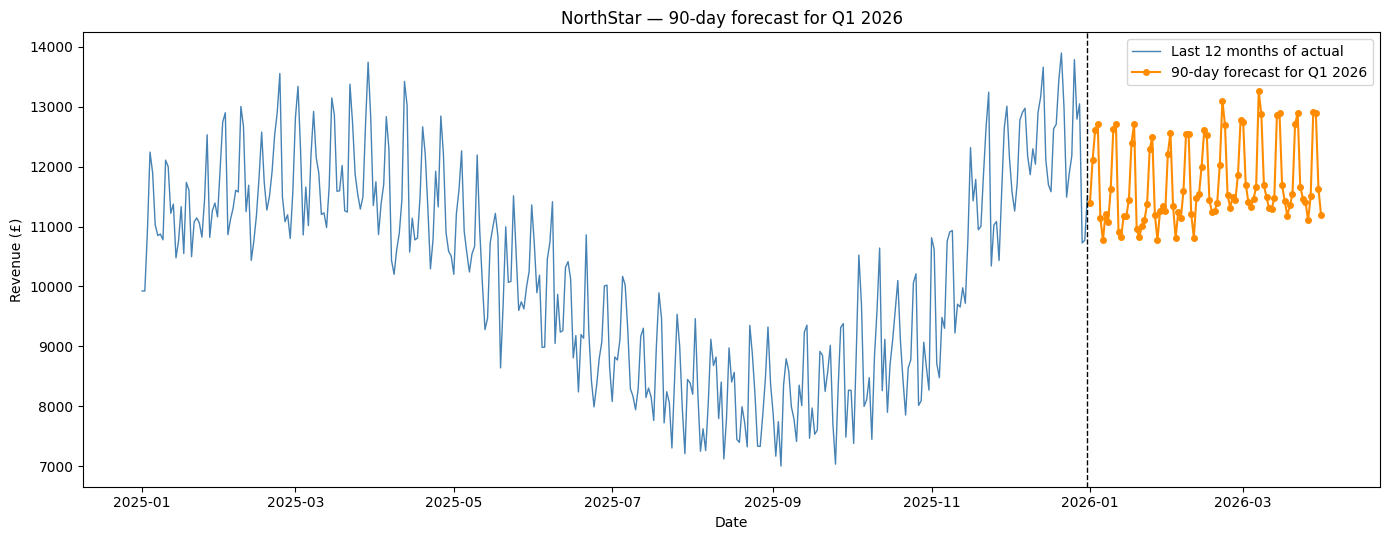

Forecasted total Q1 2026 revenue: £1,056,279
Average daily revenue:            £11,736

Sarah's Friday slide: 'Q1 2026 revenue forecast: £1,056,279 (90-day horizon).'


In [13]:
# Rebuild features with ALL data
features_all = build_features(y).dropna()
X_full = features_all.drop(columns=["target"])
y_full = features_all["target"]

# Re-train on all data
model_final = HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.05, max_depth=6,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
    random_state=42,
)
model_final.fit(X_full, y_full)

# Forecast 90 days into 2026
future_dates = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=90, freq="D")
forecast_future = recursive_forecast(model_final, history_y=y, future_index=future_dates)

# Visualise
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(y.iloc[-365:].index, y.iloc[-365:].values, color="steelblue", linewidth=1.0,
        label="Last 12 months of actual")
ax.plot(forecast_future.index, forecast_future.values, "o-", color="darkorange",
        markersize=4, linewidth=1.5, label="90-day forecast for Q1 2026")
ax.axvline(y.index[-1], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("NorthStar — 90-day forecast for Q1 2026")
ax.legend()
plt.tight_layout()
plt.show()

# Headline numbers for Marcus
total_q1 = forecast_future.sum()
mean_daily = forecast_future.mean()
print(f"Forecasted total Q1 2026 revenue: £{total_q1:,.0f}")
print(f"Average daily revenue:            £{mean_daily:,.0f}")
print()
print("Sarah's Friday slide: 'Q1 2026 revenue forecast: £{:,.0f} (90-day horizon).'".format(total_q1))

## ✅ Section Summary

**Results on the 90-day holiday test window:**

| Method | MAE | MAPE | Notes |
|---|---|---|---|
| **Naive** | ~£3,300 | ~29% | Ignores trend AND seasonality — the floor, badly undershoots the holiday run-up |
| **Seasonal Naive** | ~£2,400 | ~21% | Misses the holiday-spike trend |
| **ETS-weekly** | ~£2,250 | ~19% | Best on this single window — captures trend + weekly cycle but not annual spike |
| **ML one-step (lag_1 known)** | ~£1,400 | ~12% | One-step-ahead with yesterday's *actual* value known (not an ML-only trick — see takeaway) |
| **ML recursive (90-step)** | ~£2,440 | ~21% | Errors compound over a long horizon — single-window result, see below |

**Important caveat — single-window evaluation lies:**

On this single 90-day window ETS-weekly edges out ML recursive. But a single window is luck of the draw, so Step 9 cross-validates **every** model with `TimeSeriesSplit` over 3 rolling 90-day windows. Judged fairly that way:

| Method | Mean CV MAE |
|---|---|
| **ETS-weekly** | ~£1,550 |
| **ML recursive** | ~£1,570 |
| **Seasonal Naive** | ~£1,580 |

ETS-weekly and the ML forecaster are **essentially tied** (ETS marginally ahead) — both far better than the £2,438 ML scored on the single holiday slice, which was an unusually hard window, not the model's typical accuracy.

**The honest takeaway:** evaluate every method on CROSS-VALIDATED windows, not a single snapshot. Done fairly, ML does **not** clearly beat ETS on accuracy here — they're comparable. So accuracy isn't why you'd eventually choose ML; its real advantages are about **flexibility**:
- **Multiple seasonalities at once.** ML combines `lag_7` + `lag_365` + calendar features, modelling the weekly *and* annual cycle natively — instead of one fixed `seasonal_period` like ETS.
- **Room for exogenous drivers.** ML can fold in promotions, holidays, price changes or weather simply by adding more feature columns. ETS has no natural way to take those extra inputs.

(Note: the one-step ~12% MAPE is *not* an ML-only edge — ETS can also use yesterday's actual value when you retrain daily, so "we can retrain" doesn't favour either model.)

**Key insights:**
- **Lag features turn a time series into a tabular regression problem.** Same gradient boosting as L04 works.
- **`lag_365` is what lets ML match classical** on data with annual seasonality — without it, ML can't see the yearly pattern at all.
- **Recursive multi-step forecasting compounds errors.** For long horizons, use DIRECT forecasting (Extension 1) or retrain daily.
- **`lag_7` is the most important feature here**, with `dayofweek` close behind — the weekly cycle does most of the work on this series (importance is always data-dependent, and measured on a single window — see Step 7's caveat).
- **Evaluate on multiple windows** with `TimeSeriesSplit` — and cross-validate *all* candidates the same way; a single test window can flatter or punish any method by luck.

---

## 🏁 Friday — What Sarah Presents to Marcus

| Item | Value |
|---|---|
| **Decomposition chart** | Trend + weekly seasonal + residual (visible structure) |
| **Best classical method** | ETS-weekly (MAPE ~19% on the holiday window; mean CV MAE ~£1,550) |
| **Best ML method** | HistGradientBoostingRegressor with lag features — competitive with ETS on cross-validated rolling windows (mean CV MAE ~£1,570 vs ETS ~£1,550, Step 9) |
| **90-day forecast** | Q1 2026 total revenue: see the print output from Step 10 — the model computes the exact figure for that run |
| **Recommendation** | ETS-weekly and the ML forecaster are **tied** on cross-validated MAE (~£1,550–1,570), so accuracy alone doesn't separate them. Prefer **ML** when you need to capture **multiple seasonalities at once** (weekly + annual) or expect to add **exogenous drivers** — promotions, holidays, price changes — things ETS can't easily represent. Prefer **ETS** for simplicity and fewer moving parts when a single seasonality drives the series. Either way, re-evaluate on rolling windows before any threshold-based business action. |

Marcus nods. *"Excellent. Now — last question. If we collected DETAILED CUSTOMER BEHAVIOUR data (every click, every page view, every cart event), could you predict whether they'd complete checkout WHILE THEY'RE SHOPPING?"*

That question — **prediction from sequential behaviour with neural networks** — is the engine of **L07 (Neural Networks & Deep Learning).**

---
**Next step →** Open `assignment.ipynb` for the after-class exercises.

*Or, for ARIMA / SARIMA / Prophet / stationarity tests: open `optional_extensions.ipynb`.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Direct forecasting: separate models for each horizon

Recursive forecasting compounds errors. The alternative — **direct forecasting** — trains a SEPARATE model for each horizon (1-day-ahead, 7-day-ahead, 30-day-ahead, ...).

More work, but no error compounding.

In [14]:
# Train separate models for horizons 1, 7, 30
horizons = [1, 7, 30]
direct_models = {}
direct_preds  = {}

for h in horizons:
    # Build target: y shifted -h days (predict h days ahead)
    y_target = y.shift(-h)

    # Use same features as before
    X = build_features(y).drop(columns=["target"])
    X = X.dropna()  # remove first 365 rows
    y_target_aligned = y_target.loc[X.index]

    # Drop rows where target is NaN (last h rows of the series)
    mask = ~y_target_aligned.isna()
    X = X.loc[mask]
    y_target_aligned = y_target_aligned.loc[mask]

    # Split train/test
    split_date = y.index[-TEST_SIZE]
    X_tr = X.loc[X.index < split_date]
    y_tr = y_target_aligned.loc[X_tr.index]
    X_te = X.loc[(X.index >= split_date) & (X.index < split_date + pd.Timedelta(days=TEST_SIZE - h))]
    y_te = y_target_aligned.loc[X_te.index]

    model_h = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=42)
    model_h.fit(X_tr, y_tr)
    pred_h = model_h.predict(X_te)

    mae_h = mean_absolute_error(y_te, pred_h)
    print(f"Direct forecast at horizon {h:2d} days: MAE = £{mae_h:,.0f}  (test size {len(y_te)})")
    direct_models[h] = model_h
    direct_preds[h]  = pred_h

print()
print("→ Each direct model predicts a fixed horizon in ONE step, so it never compounds errors")
print("  the way recursive forecasting does. Whether it wins depends on the horizon and window;")
print("  it's the go-to alternative when a long recursive chain drifts badly.")

Direct forecast at horizon  1 days: MAE = £2,251  (test size 89)


Direct forecast at horizon  7 days: MAE = £2,065  (test size 83)


Direct forecast at horizon 30 days: MAE = £2,602  (test size 60)

→ Each direct model predicts a fixed horizon in ONE step, so it never compounds errors
  the way recursive forecasting does. Whether it wins depends on the horizon and window;
  it's the go-to alternative when a long recursive chain drifts badly.


## Extension 2 — Forecast confidence intervals via residual quantiles

Point forecasts are great. Point forecasts WITH ERROR BARS are better. The simplest approach: compute the residual quantiles on the training data, then forecast ± those quantiles.

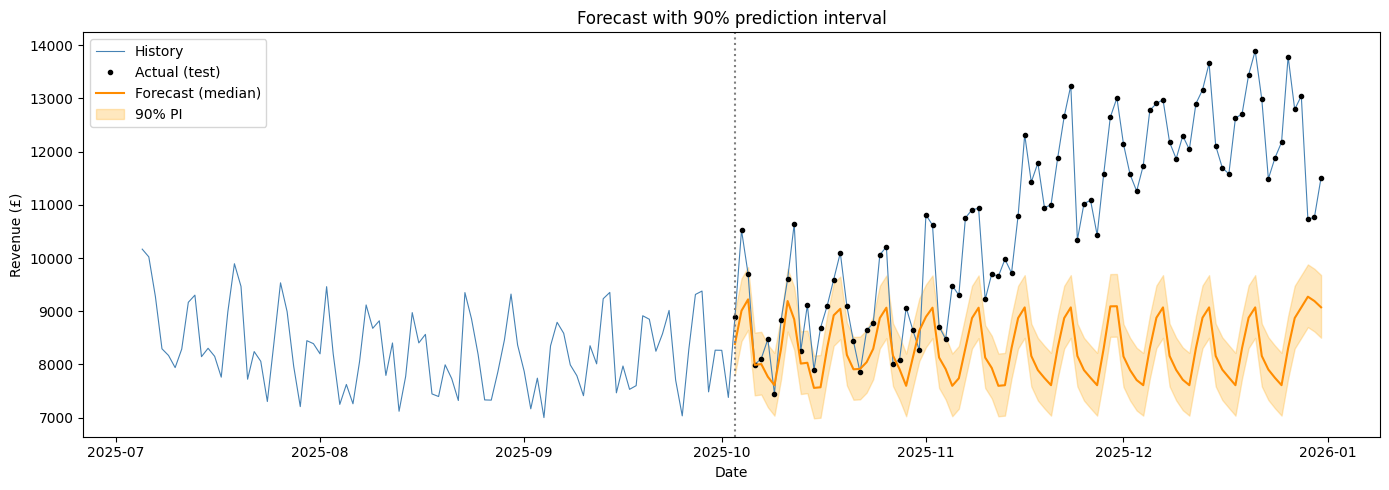

Fraction of test points inside the 90% PI: 21.1%
(Should be near 0.90 if the PI is well calibrated.)


In [15]:
# Recompute training residuals (one-step-ahead)
residuals_train = y_train - model.predict(X_train)

# 90% prediction interval = 5th and 95th percentile of residuals
lower_q, upper_q = np.quantile(residuals_train, [0.05, 0.95])

forecast_lower = y_pred_recursive + lower_q
forecast_upper = y_pred_recursive + upper_q

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.iloc[-180:].index, y.iloc[-180:].values, color="steelblue", linewidth=0.8, label="History")
ax.plot(y_test.index, y_test.values, "o", color="black", markersize=3, label="Actual (test)")
ax.plot(y_pred_recursive.index, y_pred_recursive.values, color="darkorange", linewidth=1.5,
        label="Forecast (median)")
ax.fill_between(y_pred_recursive.index, forecast_lower, forecast_upper,
                alpha=0.25, color="orange", label="90% PI")
ax.axvline(y_test.index[0], color="gray", linestyle=":")
ax.set_xlabel("Date"); ax.set_ylabel("Revenue (£)")
ax.set_title("Forecast with 90% prediction interval")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

# Coverage check
inside_pi = ((y_test >= forecast_lower) & (y_test <= forecast_upper)).mean()
print(f"Fraction of test points inside the 90% PI: {inside_pi:.1%}")
print(f"(Should be near 0.90 if the PI is well calibrated.)")

## Extension 3 — Try a small grid search for hyperparameters

In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

# Time-series cross-validated grid search
tscv_ml = TimeSeriesSplit(n_splits=4, test_size=30)

grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter":      [100, 200],
    "max_depth":     [4, 6, None],
}

base_model = HistGradientBoostingRegressor(
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, random_state=42,
)

search = GridSearchCV(
    base_model, grid, cv=tscv_ml,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV MAE: £{-search.best_score_:,.0f}")

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'max_iter': 200}
Best CV MAE: £626
